# ESPM Course 2025 
## Second notebook
Simple diffusion equation (same as in Notebook 1) but solved using an implicit scheme

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import numba

We try to solve the time-dependent diffusion equation:
$$\frac{\partial h}{\partial t}=K_d\frac{\partial^2h}{\partial x^2}$$
with the following initial condition:
$$h(t=0)=h_0\sin(2\pi nx/L)$$
and boundary conditions:
$$h(x=0;x=L)=0$$
using a centered-difference, implict finite difference scheme:
$$h_i(t+\Delta t)=h_i(t)+\frac{\Delta tK_d}{\Delta x^2}(h_{i+1}(t+\Delta t)-2h_i(t+\Delta t)+h_{i-1}(t+\Delta t))$$

This leads to the solution of a system of algebraic equations that has a tridiagonal form:
$$Ah=b$$
The diagonal term is given by:
$$A_{i,i}=1+2\frac{K_d\Delta t}{\Delta x^2}$$
and the off-diagonal terms are given by:
$$A_{i,i-1}=A_{i+1,i}=-\frac{K_d\Delta t}{\Delta x^2}$$
To solve such a system, we use a tridiagonal matrix solver derived from Numerical Recipes.

In [6]:
@numba.njit
def tridag(a, b, c, r):
    """
    Function to solve a tri-diagonal system of equations
    a is lower diagonal, b is diagonal, c is upper diagonal, r is rhigh hand side
    tridag returns an array of size n containing the solution to the system of equations
    """

    n = len(r)
    res = np.empty(n)
    gam = np.empty(n)

    if b[0] == 0:
        raise RuntimeError("diagonal contains nil element in tridag")

    bet = b[0]
    res[0] = r[0] / bet
    for j in range(1, n):  # in Fortran the range is 2,n
        gam[j] = c[j - 1] / bet
        bet = b[j] - a[j] * gam[j]
        if bet == 0:
            raise RuntimeError("diagonal contains nil element in tridag")
        res[j] = (r[j] - a[j] * res[j - 1]) / bet

    for j in range(n - 2, -1, -1):  # in Fortran the range is n-1,1,-1
        res[j] = res[j] - gam[j + 1] * res[j + 1]

    return res

In [7]:
xl = 1000 # (m)
nx = 101
x = np.linspace(0, xl, nx)
dx = xl/(nx - 1)
Kd = 1e-2 # (m^2/yr)
n = 1
h0 = 1 # (m)
taun = xl**2/Kd/4/np.pi**2/n**2
dt = taun/1e3
nstep = 1000

courant = dt*Kd/dx**2
print(taun,dt,courant)

2533029.591058444 2533.029591058444 0.25330295910584444


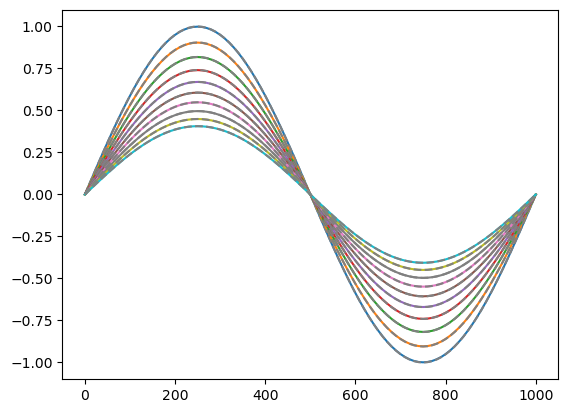

In [9]:
h = h0*np.sin(x/xl*2*np.pi*n)

diag = np.ones_like(x)*(1 + 2*courant)
sup = np.ones_like(x)*(-courant)
sub = np.ones_like(x)*(-courant)
diag[0] = 1
diag[-1] = 1
sup[0] = 0
sub[-1] = 0
for step in range(nstep):
    h = tridag(sub, diag, sup, h)
    if step%(nstep/10)==0:
        plt.plot(x, h, label=f'step {step}')
        ha = h0*np.sin(2*np.pi*x*n/xl)*np.exp(-dt*step/taun)
        plt.plot(x, ha, '--', c='grey')
